In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn import tree

In [3]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR

In [4]:
import warnings
warnings.filterwarnings("ignore")

In [5]:
df = pd.read_csv("insurance.csv")

In [6]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [8]:
df.duplicated().sum()

np.int64(1)

In [9]:
df[df.duplicated()]

,age,sex,bmi,children,smoker,region,charges
581,19,male,30.59,0,no,northwest,1639.5631


In [10]:
df = df.drop_duplicates()
df.shape

(1337, 7)

In [11]:
df.describe()

,age,bmi,children,charges
count,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,30.663452,1.095737,13279.121487
std,14.044333,6.100468,1.205571,12110.359656
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.290000,0.000000,4746.344000
50%,39.000000,30.400000,1.000000,9386.161300
75%,51.000000,34.700000,2.000000,16657.717450
max,64.000000,53.130000,5.000000,63770.428010


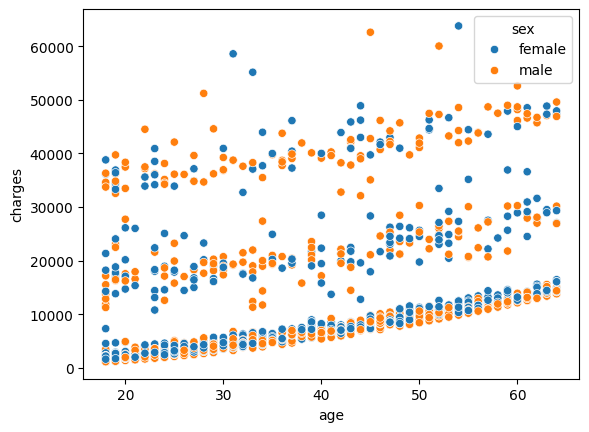

In [12]:
sns.scatterplot(data=df, x="age", y="charges", hue="sex")
plt.show()

In [14]:
categorical_columns = ["sex", "smoker", "region"]
numerical_columns = ["age", "bmi", "children"]

In [15]:
X = df.drop("charges", axis=1)
y = df["charges"]

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=15)

In [17]:
one_hot_encoder = OneHotEncoder(handle_unknown="ignore")
scaler = StandardScaler()

preprocessor = ColumnTransformer(
    transformers=[
        ("one_hot", one_hot_encoder, categorical_columns),
        ("scale", scaler, numerical_columns),
    ],
    remainder="passthrough"
)

In [18]:
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)
X_test_transformed.shape

(402, 11)

In [19]:
dec_tree_reg = DecisionTreeRegressor()

params_tree = {
    "criterion": ["squared_error", "friedman_mse", "absolute_error", "poisson"],
    "splitter": ["best", "random"],
    "max_depth": [2, 3, 4, 5, 8, 10, 15, None],
    "max_features": ["sqrt", "log2", None],
}

grid_tree = GridSearchCV(estimator=dec_tree_reg, param_grid=params_tree,cv=5)

In [20]:
grid_tree.fit(X_train_transformed, y_train)

y_pred_tree = grid_tree.predict(X_test_transformed)

print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred_tree))
print("Mean Squared Error:", mean_squared_error(y_test, y_pred_tree))
print("R2 Score:", r2_score(y_test, y_pred_tree))

Mean Absolute Error: 2771.944861975212
Mean Squared Error: 21193175.79421298
R2 Score: 0.8528956356480539


In [21]:
grid_tree.best_params_

{'criterion': 'squared_error',
 'max_depth': 4,
 'max_features': None,
 'splitter': 'best'}

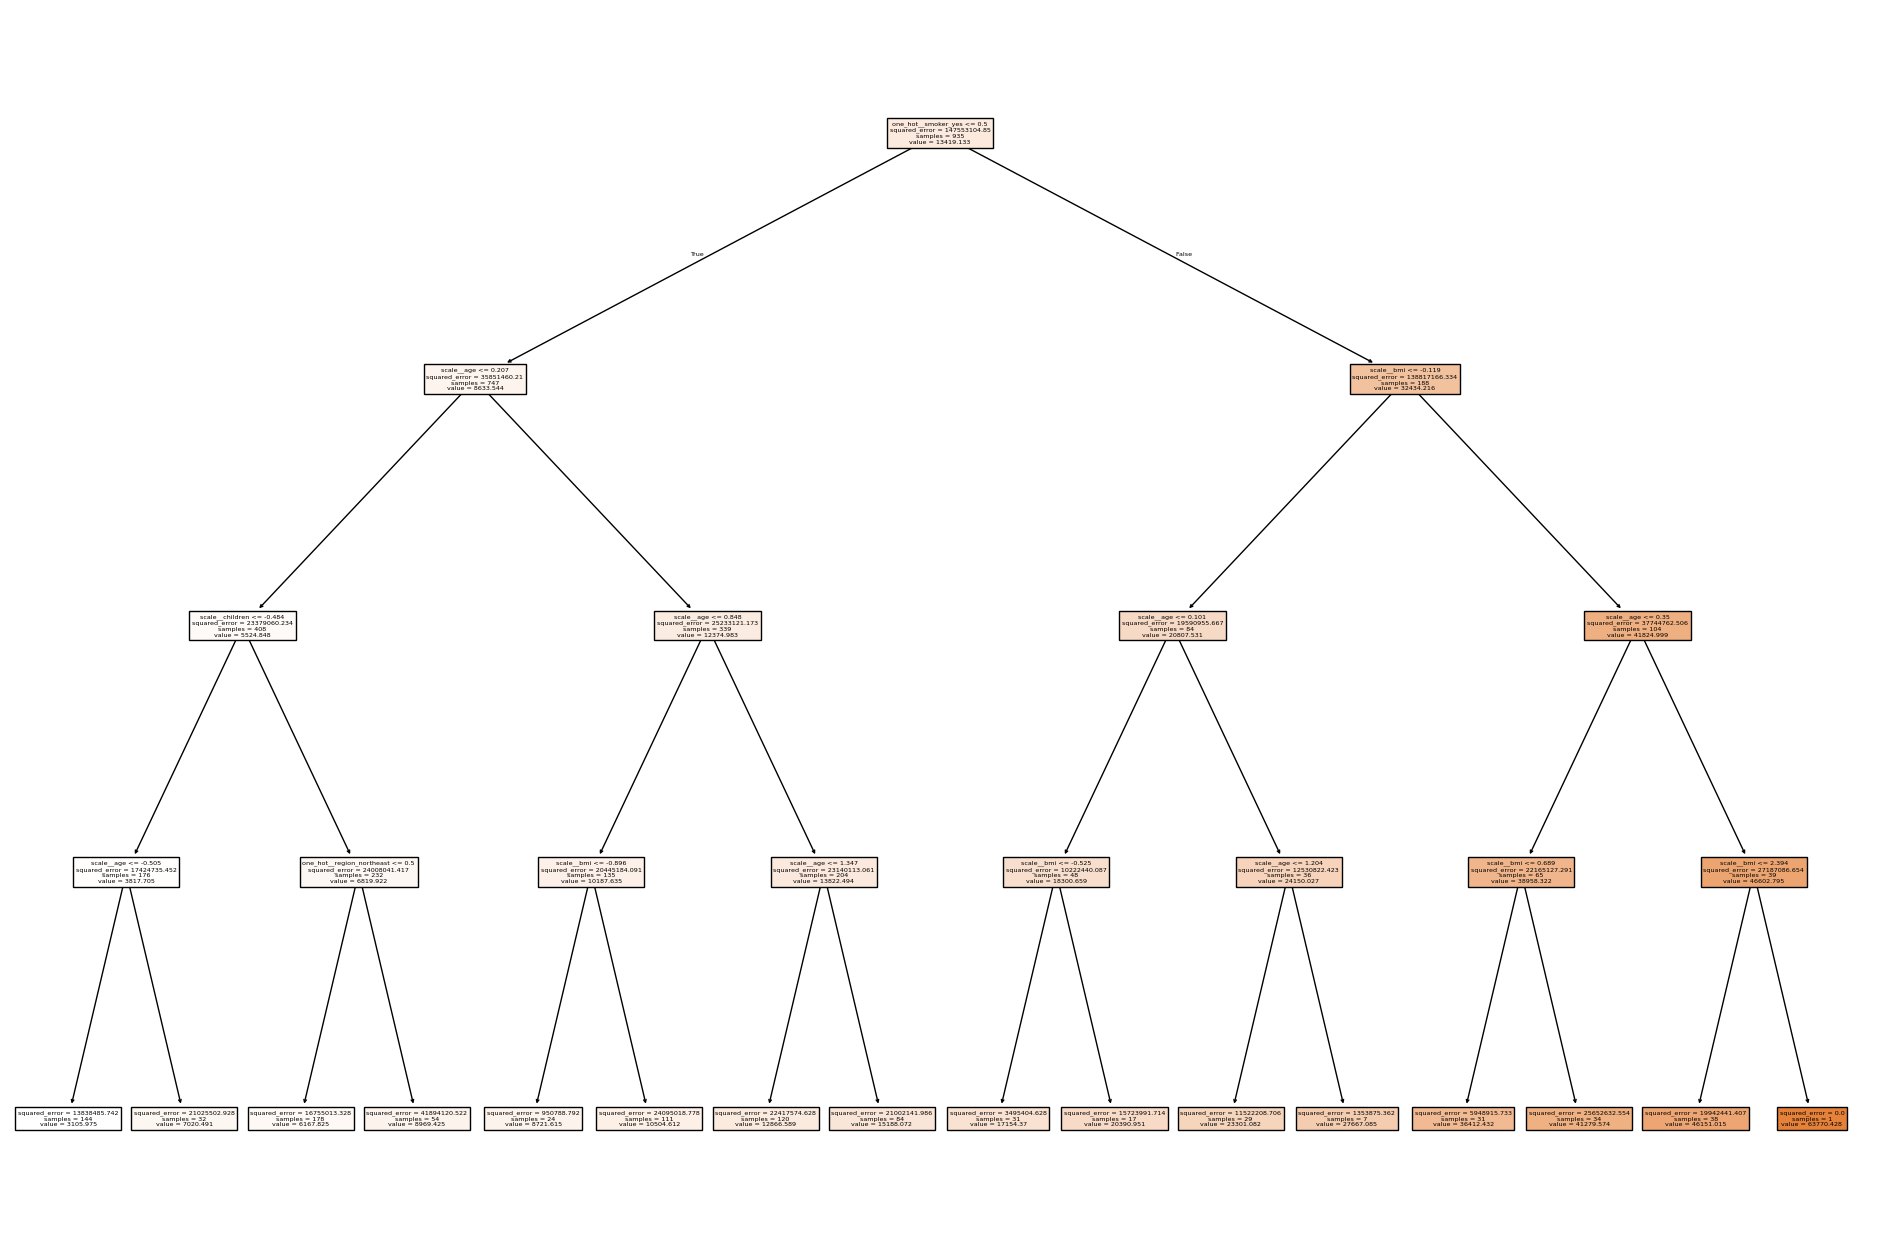

In [ ]:
plt.figure(figsize=(24,16))

columns_name = preprocessor.get_feature_names_out()

tree.plot_tree(grid_tree.best_estimator_, feature_names=columns_name, filled=True)
plt.show()

In [23]:
lin_reg = LinearRegression()
lin_reg.fit(X_train_transformed, y_train)

y_pred_linear = lin_reg.predict(X_test_transformed)
r2_linear = r2_score(y_test, y_pred_linear)

print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred_linear))
print("Mean Squared Error:", mean_squared_error(y_test, y_pred_linear))
print("R2 Score:", r2_linear)

Mean Absolute Error: 4221.868582419835
Mean Squared Error: 34868081.242827594
R2 Score: 0.7579764836943994


In [25]:
svr = SVR()

params_svr = [
    {
        "kernel": ["rbf", "linear", "poly"],
        "gamma": ["scale", "auto"],
        "C": [100, 10, 1]
    }
]

grid_svr = GridSearchCV(estimator=svr,param_grid=params_svr,cv=5,verbose=3)

grid_svr.fit(X_train_transformed, y_train)

y_pred_svr = grid_svr.predict(X_test_transformed)

Fitting 5 folds for each of 18 candidates, totalling 90 fits
[CV 1/5] END ....C=100, gamma=scale, kernel=rbf;, score=0.042 total time=   0.0s
[CV 2/5] END ....C=100, gamma=scale, kernel=rbf;, score=0.017 total time=   0.0s
[CV 3/5] END ....C=100, gamma=scale, kernel=rbf;, score=0.051 total time=   0.0s
[CV 4/5] END ....C=100, gamma=scale, kernel=rbf;, score=0.042 total time=   0.0s
[CV 5/5] END ...C=100, gamma=scale, kernel=rbf;, score=-0.011 total time=   0.0s
[CV 1/5] END .C=100, gamma=scale, kernel=linear;, score=0.527 total time=   0.0s
[CV 2/5] END .C=100, gamma=scale, kernel=linear;, score=0.539 total time=   0.0s
[CV 3/5] END .C=100, gamma=scale, kernel=linear;, score=0.559 total time=   0.0s
[CV 4/5] END .C=100, gamma=scale, kernel=linear;, score=0.542 total time=   0.0s
[CV 5/5] END .C=100, gamma=scale, kernel=linear;, score=0.531 total time=   0.0s
[CV 1/5] END ...C=100, gamma=scale, kernel=poly;, score=0.045 total time=   0.0s
[CV 2/5] END ...C=100, gamma=scale, kernel=poly;

In [26]:
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred_svr))
print("Mean Squared Error:", mean_squared_error(y_test, y_pred_svr))
print("R2 Score:", r2_score(y_test, y_pred_svr))

Mean Absolute Error: 3580.10199556571
Mean Squared Error: 55657617.85090717
R2 Score: 0.6136738271412395


In [29]:
print("Best Parameters:\n", grid_svr.best_params_, "\n")
print("Best Model:\n", grid_svr.best_estimator_)

Best Parameters:
 {'C': 100, 'gamma': 'scale', 'kernel': 'linear'} 

Best Model:
 SVR(C=100, kernel='linear')


In [30]:
results = {
    "Model": ["Decision Tree Regressor", "Linear Regression", "SVR"],
    "Best Score": [grid_tree.best_score_, r2_linear, grid_svr.best_score_],
    "Hyperparameter Tuning (GridSearchCV)": ["Yes", "No", "Yes"],
    "Best Parameters": [grid_tree.best_params_, "--", grid_svr.best_params_]
 }


results_df = pd.DataFrame(results)

results_df = results_df.sort_values(by="Best Score", ascending=False)
display(results_df)

,Model,Best Score,Hyperparameter Tuning (GridSearchCV),Best Parameters
0,Decision Tree Regressor,0.844068,Yes,"{'criterion': 'squared_error', 'max_depth': 4,..."
1,Linear Regression,0.757976,No,--
2,SVR,0.539529,Yes,"{'C': 100, 'gamma': 'scale', 'kernel': 'linear'}"
